# **Simulasi Rute dan Jadwal Perjalanan Anjangsana | Dijkstra**

Model yang bertujuan mencari rute dan jadwal perjalanan pada kegiatan anjangsana menggunakan algoritma Dijkstra.

Dikerjakan oleh: 
- Akhyar Bima
- Silmy Muthi'ah Aulya

SMK Negeri 2 Singosari

## 1. Analytical Solutions

### 1.1 Import Library

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import tkinter as tk
from tkinter import ttk

### 1.2 Read Dataset 

In [2]:
# Impor dataset
df = pd.read_csv('Data Set SMK - Data Fix.csv')
df.to_csv('data_fix.csv', index=False)

In [3]:
# 5 baris pertama
print('\n5 baris pertama:')
df.head()


5 baris pertama:


,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240


In [4]:
# 10 baris acak
print('\n10 baris acak:') 
df.sample(10)


10 baris acak:


,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah
38,3.357930e+15,Maria,"Jember, 21-08-1997",anak,belum kawin,"Rp6.753.323,84",Swasta,Islam,opor,C2,240
8,3.356070e+15,Pak Suprapto,"jember, 21-02-1975",Kepala Keluarga,kawin,"Rp2.789.583,37",PNS,Islam,bakso,C1,200
11,3.356720e+15,Bu Fahmi,"semarang, 28-06-1978",Istri,kawin,"Rp12.574.754,56",BUMN,Islam,opor,C2,240
9,3.352750e+15,Bu Suprapto,"jember, 22-04-1977",Istri,kawin,"Rp6.430.981,43",Swasta,Islam,bakso,C1,200
21,3.356390e+15,Bu Hari,"Malang, 09-10-1986",Istri,kawin,"Rp6.320.220,80",PNS,Islam,opor,C7,200
62,3.358860e+15,Akbar,"Jember, 09 Agustus 1999",anak,belum kawin,"Rp1.077.428,32",Swasta,Islam,soto,C10,180
48,3.353400e+15,Tina,"Jember, 21-04-2000",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,rawon,C5,240
10,3.356810e+15,Pak Fahmi,"jember, 14-08-1978",Kepala Keluarga,kawin,"Rp2.727.962,40",Swasta,Islam,opor,C2,240
29,3.357690e+15,Bu Mardi,"Jember, 02-05-1988",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,opor,C11,100
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240


In [5]:
# Dimensi dataset
print('\nDimensi dataset:')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')


Dimensi dataset:
Jumlah baris: 75
Jumlah kolom: 11


In [6]:
# Ringkasan informasi dataset
print('\nInformasi dataset:')
df.info()



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NIK                75 non-null     float64
 1   Nama               75 non-null     object 
 2   TTL                75 non-null     object 
 3   Status Hubungan    75 non-null     object 
 4   Status Perkawinan  75 non-null     object 
 5   Gaji               75 non-null     object 
 6   Jenis Pekerjaan    75 non-null     object 
 7   Agama              75 non-null     object 
 8   Jenis Makanan      75 non-null     object 
 9   Kode Rumah         75 non-null     object 
 10  Luas Rumah         75 non-null     int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 6.6+ KB


In [7]:
# Ringkasan statistik
print('\nRingkasan statistik:')
df.describe()



Ringkasan statistik:


,NIK,Luas Rumah
count,7.500000e+01,75.000000
mean,3.356232e+15,194.800000
std,2.017711e+12,48.750884
min,3.352750e+15,100.000000
25%,3.354405e+15,180.000000
50%,3.356150e+15,200.000000
75%,3.357795e+15,235.000000
max,3.359990e+15,280.000000


In [8]:
df['Agama'].value_counts()

Agama
Islam      70
Kristen     5
Name: count, dtype: int64

In [9]:
df['Kode Rumah'].value_counts()

Kode Rumah
C3     6
C6     6
C13    5
C10    5
C2     5
C5     5
C12    5
C7     5
C8     5
C9     4
C11    4
C14    4
C4     4
C1     4
B1     2
A1     2
B3     2
B2     2
Name: count, dtype: int64

### 1.3 Data Cleaning

#### 1.3.1 Missing Value

In [10]:
# Cek nilai kosong
print('\nTotal nilai kosong:', df.isnull().sum().sum())


Total nilai kosong: 0


#### 1.3.2 Nilai Duplikat

In [11]:
# Cek nilai duplikat
print('\nTotal nilai duplikat:', df.duplicated().sum())


Total nilai duplikat: 0


### 1.5 Data Preprocessing

In [12]:
df['TTL'].unique()

array(['jember, 28-07-1933', 'jember, 12-07-1940', 'jember, 01-07-1963',
       'jember, 15-03-1966', 'jember, 14-12-1965', 'Pemalang, 07-08-1966',
       'jember, 11-09-1968', 'jember, 09-09-1968', 'jember, 21-02-1975',
       'jember, 22-04-1977', 'jember, 14-08-1978', 'semarang, 28-06-1978',
       'jember, 10-04-1979', 'jember, 06-03-1980', 'jember, 11-09-1980',
       'Jakarta, 11-04-1986', 'Malang, 07-06-1980', 'jember, 06-08-1983',
       'Jember, 12-07-1979', 'Jember, 08-09-1984', 'Malang, 09-10-1986',
       'Jember, 21-11-1985', 'Situbodo, 19-09-1986',
       'Banyuwangi, 07-02-1983', 'Jember, 20-12-1986',
       'Jember,10-04-1987', 'Surabaya, 14-02-1988', 'Madiun, 29-03-1987',
       'Jember, 02-05-1988', 'Jember, 07-08-1989', 'Bekasi, 01-10-1990',
       'Jember, 27-05-1991', 'Malang, 30-06-1992',
       'Banyuwangi, 07-02-1991', 'Jember, 27-05-1992',
       'Jember, 21-08-1998', 'Jember, 18-04-2001', 'Jember, 21-08-1997',
       'Jember, 02-09-1999', 'Jember, 17-10-2000',

In [13]:
df.head()

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240


In [14]:
# Fungsi untuk membersihkan nama bulan Indonesia
def clean_indo_date(text):
    if pd.isna(text): return text
    bulan_indo = {
        'Januari': '01', 'Februari': '02', 'Maret': '03', 'April': '04',
        'Mei': '05', 'Juni': '06', 'Juli': '07', 'Agustus': '08',
        'September': '09', 'Oktober': '10', 'November': '11', 'Desember': '12'
    }
    # Ambil bagian setelah koma
    parts = text.split(',')
    if len(parts) < 2: return text
    date_str = parts[1].strip()
    
    # Ganti nama bulan jika ada
    for indo, num in bulan_indo.items():
        if indo in date_str:
            date_str = date_str.replace(indo, num).replace(' ', '-')
    return date_str

# 1. Terapkan pembersihan
df['date_cleaned'] = df['TTL'].apply(clean_indo_date)

# 2. Konversi ke datetime (sekarang semua sudah format DD-MM-YYYY atau DD-NamaBulan-YYYY yang sudah diganti)
df['tanggal_dt'] = pd.to_datetime(df['date_cleaned'], dayfirst=True, errors='coerce')

# 3. Hitung Umur (Gunakan tahun 2025 sesuai konteks saat ini)
df['umur'] = 2025 - df['tanggal_dt'].dt.year

# 4. Jalankan Filter Anak (Syarat: Umur <= 17)
# Contoh: Tahun 2008 -> Umur 17 (Masuk kategori anak)
df_anak = df[df['umur'] <= 17].copy()

print(f"Jumlah anak ditemukan: {len(df_anak)}")
print(df_anak[['Nama', 'umur', 'TTL']])

Jumlah anak ditemukan: 7
       Nama  umur                        TTL
56    Barni    16    Jember, 08 Agustus 2009
60   Farhan    17      Jember, 14 Maret 2008
61    Fikri    13  Jember, 01 September 2012
64     Roni    17    Jember, 11 Agustus 2008
70  Chintya    17  Jember, 07 September 2008
71    Fania    15    Jember, 11 Agustus 2010
72      Aji     9   Jember, 19 November 2016


In [15]:
df.head()

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah,date_cleaned,tanggal_dt,umur
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280,28-07-1933,1933-07-28,92
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280,12-07-1940,1940-07-12,85
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240,01-07-1963,1963-07-01,62
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240,15-03-1966,1966-03-15,59
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240,14-12-1965,1965-12-14,60


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   NIK                75 non-null     float64       
 1   Nama               75 non-null     object        
 2   TTL                75 non-null     object        
 3   Status Hubungan    75 non-null     object        
 4   Status Perkawinan  75 non-null     object        
 5   Gaji               75 non-null     object        
 6   Jenis Pekerjaan    75 non-null     object        
 7   Agama              75 non-null     object        
 8   Jenis Makanan      75 non-null     object        
 9   Kode Rumah         75 non-null     object        
 10  Luas Rumah         75 non-null     int64         
 11  date_cleaned       75 non-null     object        
 12  tanggal_dt         75 non-null     datetime64[ns]
 13  umur               75 non-null     int32         
dtypes: datetime6

In [17]:
df['umur'].unique()

array([92, 85, 62, 59, 60, 57, 50, 48, 47, 46, 45, 39, 42, 41, 40, 38, 37,
       36, 35, 34, 33, 27, 24, 28, 26, 25, 23, 21, 16, 22, 19, 17, 13, 15,
        9, 18], dtype=int32)

In [18]:
# hitung umur berdasarkan tahun lahir
df['umur'] = 2025 - df['tanggal_dt'].dt.year
df.head(20)

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah,date_cleaned,tanggal_dt,umur
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280,28-07-1933,1933-07-28,92
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280,12-07-1940,1940-07-12,85
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240,01-07-1963,1963-07-01,62
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240,15-03-1966,1966-03-15,59
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240,14-12-1965,1965-12-14,60
5,3.354390e+15,Bu Pardi,"Pemalang, 07-08-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,B2,240,07-08-1966,1966-08-07,59
6,3.352830e+15,Pak Udin,"jember, 11-09-1968",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,ayam bakar,B3,260,11-09-1968,1968-09-11,57
7,3.359840e+15,Bu Udin,"jember, 09-09-1968",Istri,kawin,"Rp3.000.000,00",Pensiunan,Islam,ayam bakar,B3,260,09-09-1968,1968-09-09,57
8,3.356070e+15,Pak Suprapto,"jember, 21-02-1975",Kepala Keluarga,kawin,"Rp2.789.583,37",PNS,Islam,bakso,C1,200,21-02-1975,1975-02-21,50
9,3.352750e+15,Bu Suprapto,"jember, 22-04-1977",Istri,kawin,"Rp6.430.981,43",Swasta,Islam,bakso,C1,200,22-04-1977,1977-04-22,48


### 1.6 Exploratory Data Analysis (EDA)

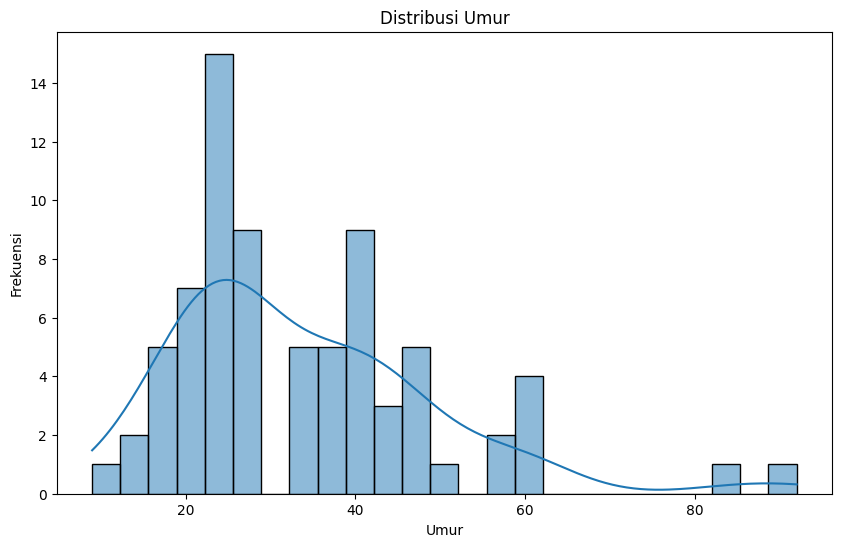

In [19]:
# visualisasi distribusi umur
plt.figure(figsize=(10, 6))
sns.histplot(df['umur'], bins=25, kde=True)
plt.title('Distribusi Umur')
plt.xlabel('Umur')
plt.ylabel('Frekuensi') 
plt.show()

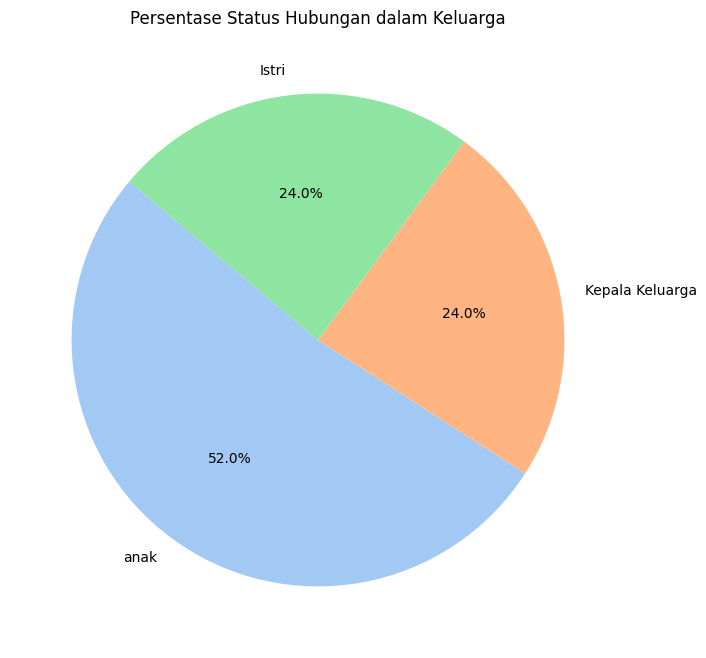

In [20]:
# 1. Menghitung frekuensi setiap status hubungan
status_counts = df['Status Hubungan'].value_counts()

# 2. Membuat Grafik Pie
plt.figure(figsize=(8, 8))
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Persentase Status Hubungan dalam Keluarga')
plt.show()

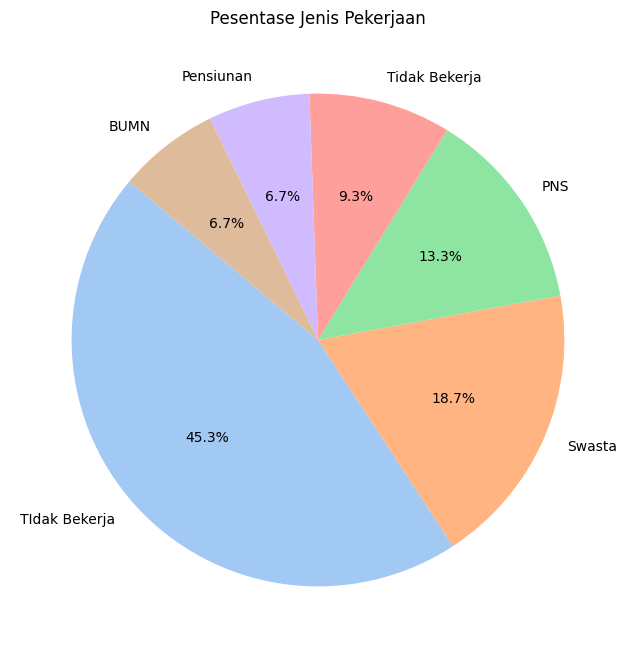

In [21]:
# 1. Menghitung frekuensi setiap status hubungan
status_counts = df['Jenis Pekerjaan'].value_counts()

# 2. Membuat Grafik Pie
plt.figure(figsize=(8, 8))
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Pesentase Jenis Pekerjaan')
plt.show()

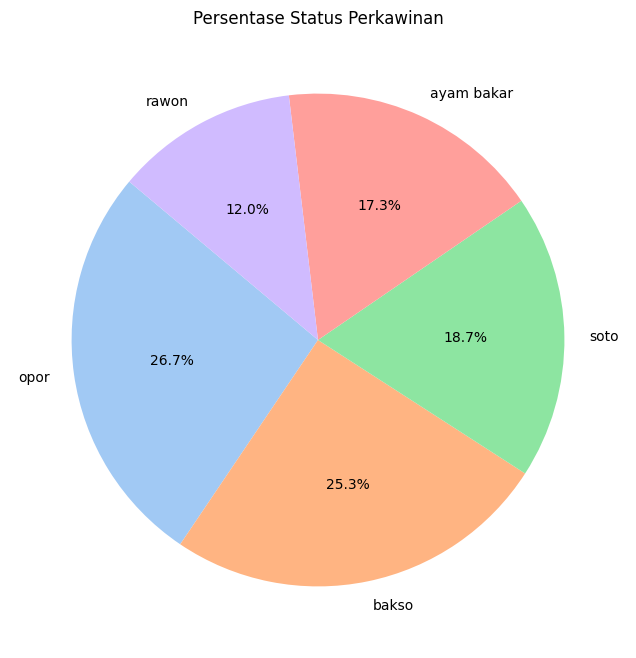

In [22]:

# 1. Menghitung frekuensi setiap status hubungan
status_counts = df['Jenis Makanan'].value_counts()

# 2. Membuat Grafik Pie
plt.figure(figsize=(8, 8))
plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Persentase Status Perkawinan')
plt.show()

In [23]:
df.head()

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah,date_cleaned,tanggal_dt,umur
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280,28-07-1933,1933-07-28,92
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280,12-07-1940,1940-07-12,85
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240,01-07-1963,1963-07-01,62
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240,15-03-1966,1966-03-15,59
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240,14-12-1965,1965-12-14,60


In [24]:
# Daftar semua titik/node dari gambar
nodes = ['C14', 'C8', 'B1', 'C6', 'C9', 'C2', 'C5', 'C1', 'A1', 'B2', 'C3', 'C11', 'B3', 'C10', 'C12', 'C13', 'C4', 'C7']
n = len(nodes)

# Membuat Matriks Jarak Kosong (Nilai tak terhingga)
dist_matrix = pd.DataFrame(np.inf, index=nodes, columns=nodes)
np.fill_diagonal(dist_matrix.values, 0)

# Isi jarak berdasarkan gambar (Contoh beberapa jalur utama)
dist_matrix.loc['C14', ['C8', 'C6', 'B1']] = [400, 300, 200]
dist_matrix.loc['B1', ['C14', 'C5', 'C9']] = [200, 200, 200]
dist_matrix.loc['C6', ['C14', 'C8', 'C1', 'A1']] = [300, 200, 400, 400]
dist_matrix.loc['C9', ['B1', 'C3', 'C11']] = [200, 400, 200]
dist_matrix.loc['C2', ['C8', 'C1']] = [400, 400]
dist_matrix.loc['C1', ['C2', 'C6', 'C7']] = [400, 400, 300]
dist_matrix.loc['C7', ['C1', 'A1', 'C4']] = [300, 300, 400]
dist_matrix.loc['A1', ['C6', 'C7', 'C4', 'B2']] = [400, 300, 400, 100]
dist_matrix.loc['C4', ['C7', 'A1', 'C13']] = [400, 400, 300]
dist_matrix.loc['C13', ['C4', 'B2', 'C12']] = [300, 300, 300]
dist_matrix.loc['B2', ['C5', 'A1', 'C13', 'C12', 'C3']] = [200, 100, 300, 200, 100]
dist_matrix.loc['C12', ['C13', 'B2', 'C10']] = [300, 200, 300]
dist_matrix.loc['C3', ['C5', 'B2', 'C9', 'C10', 'C11']] = [400, 100, 400, 200, 200]
dist_matrix.loc['C10', ['C12', 'C3', 'B3']] = [300, 200, 100]
dist_matrix.loc['C11', ['C9', 'C3', 'B3']] = [200, 200, 400]
dist_matrix.loc['B3', ['C10', 'C11']] = [100, 400]


In [25]:
def dijkstra(matrix, start_node):
    unvisited = list(matrix.index)
    distances = {node: np.inf for node in unvisited}
    distances[start_node] = 0
    predecessors = {node: None for node in unvisited}

    while unvisited:
        # Cari node dengan jarak terkecil
        current_node = min(unvisited, key=lambda node: distances[node])
        unvisited.remove(current_node)

        for neighbor in matrix.index:
            if matrix.loc[current_node, neighbor] != np.inf:
                new_dist = distances[current_node] + matrix.loc[current_node, neighbor]
                if new_dist < distances[neighbor]:
                    distances[neighbor] = new_dist
                    predecessors[neighbor] = current_node
    return distances, predecessors

In [26]:
# Hitung jarak dari rumah awal (C14) ke semua titik
jarak_ke_semua, rute_semua = dijkstra(dist_matrix, 'C14')

df['jarak_dari_pusat'] = df['Kode Rumah'].map(jarak_ke_semua)

# Buat Jadwal: Prioritas Umur > 60 dan Jarak Terpendek
jadwal = df.sort_values(by=['umur', 'jarak_dari_pusat'], ascending=[False, True])

print(jadwal[['Nama', 'Kode Rumah', 'umur', 'jarak_dari_pusat', 'Jenis Makanan']].head(20))

            Nama Kode Rumah  umur  jarak_dari_pusat Jenis Makanan
0     Pak Sutajo         A1    92             700.0         rawon
1      Bu Sutajo         A1    85             700.0         rawon
2       Pak Jais         B1    62             200.0         bakso
4      Pak Pardi         B2    60             800.0         rawon
3        Bu Jais         B1    59             200.0         bakso
5       Bu Pardi         B2    59             800.0         rawon
6       Pak Udin         B3    57            1000.0    ayam bakar
7        Bu Udin         B3    57            1000.0    ayam bakar
8   Pak Suprapto         C1    50             700.0         bakso
9    Bu Suprapto         C1    48             700.0         bakso
10     Pak Fahmi         C2    47            1100.0          opor
11      Bu Fahmi         C2    47            1100.0          opor
18     Pak Parjo         C6    46             300.0    ayam bakar
12     Pak Karno         C3    46             800.0          opor
16      Pa

In [27]:


# Daftar node sesuai peta
nodes = ['C14', 'C8', 'B1', 'C6', 'C9', 'C2', 'C5', 'C1', 'A1', 'B2', 'C3', 'C11', 'B3', 'C10', 'C12', 'C13', 'C4', 'C7']
time_matrix = pd.DataFrame(np.inf, index=nodes, columns=nodes)
np.fill_diagonal(time_matrix.values, 0)

# Fungsi pembantu untuk mengisi dua arah sekaligus
def add_time(a, b, t):
    time_matrix.loc[a, b] = t
    time_matrix.loc[b, a] = t

# Jalur Baris Bawah (Area Pak Baim & Kakek Jais)
add_time('C14', 'C8', 25)
add_time('C14', 'C6', 20)
add_time('C14', 'B1', 15)
add_time('B1', 'C5', 15)
add_time('B1', 'C9', 15)
add_time('C9', 'C3', 25)
add_time('C9', 'C11', 15)
add_time('C11', 'B3', 25)

# Jalur Baris Tengah (Area Pak Parjo & Pak Joko)
add_time('C8', 'C2', 25)
add_time('C8', 'C6', 15)
add_time('C6', 'C1', 25)
add_time('C6', 'A1', 25)
add_time('C6', 'C5', 10)
add_time('C5', 'B2', 15)
add_time('C5', 'C3', 25)
add_time('C3', 'B2', 10)
add_time('C3', 'C10', 15)
add_time('C3', 'C11', 15)
add_time('B3', 'C10', 10)

# Jalur Baris Atas (Area Kakek Sutajo & Pak Qodri)
add_time('C2', 'C1', 25)
add_time('C1', 'C7', 20)
add_time('C1', 'A1', 20)
add_time('C7', 'C4', 25)
add_time('C7', 'A1', 25)
add_time('C4', 'A1', 25)
add_time('C4', 'C13', 20)
add_time('A1', 'B2', 10)
add_time('A1', 'C13', 20)
add_time('B2', 'C12', 15)
add_time('C13', 'C12', 20)
add_time('C12', 'C10', 20)

In [28]:
# Hitung jarak/waktu terpendek dari C14
waktu_per_node, _ = dijkstra(time_matrix, 'C14')
df['waktu_perjalanan'] = df['Kode Rumah'].map(waktu_per_node)

# Hitung durasi kunjung berdasarkan luas di gambar
# Contoh mapping luas (C14:180, B1:240, dll)
df['durasi_kunjung'] = np.where(df['Luas Rumah'] > 200, 30, 15)

# Urutkan rute dan hitung akumulasi
df_rute = df.sort_values('waktu_perjalanan').copy()
df_rute['total_waktu_menit'] = df_rute['waktu_perjalanan'] + df_rute['durasi_kunjung']
df_rute['akumulasi'] = df_rute['total_waktu_menit'].cumsum()

# Pembagian Hari (480 menit per hari)
df_rute['Hari'] = (df_rute['akumulasi'] // 480).astype(int) + 1



In [29]:
df_rute.shape

(75, 20)

In [30]:
df_rute.columns

Index(['NIK', 'Nama', 'TTL', 'Status Hubungan', 'Status Perkawinan', 'Gaji',
       'Jenis Pekerjaan', 'Agama', 'Jenis Makanan', 'Kode Rumah', 'Luas Rumah',
       'date_cleaned', 'tanggal_dt', 'umur', 'jarak_dari_pusat',
       'waktu_perjalanan', 'durasi_kunjung', 'total_waktu_menit', 'akumulasi',
       'Hari'],
      dtype='object')

In [31]:
df_rute.head(10)

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah,date_cleaned,tanggal_dt,umur,jarak_dari_pusat,waktu_perjalanan,durasi_kunjung,total_waktu_menit,akumulasi,Hari
34,3.359890e+15,Pak Baim,"Banyuwangi, 07-02-1991",Kepala Keluarga,kawin,"Rp8.302.140,05",BUMN,Islam,soto,C14,180,07-02-1991,1991-02-07,34,0.0,0.0,15,15.0,15.0,1
35,3.358350e+15,Bu Baim,"Jember, 27-05-1992",Istri,kawin,"Rp5.322.783,11",Swasta,Islam,soto,C14,180,27-05-1992,1992-05-27,33,0.0,0.0,15,15.0,30.0,1
73,3.358450e+15,Mail,"Jember, 17 Februari 2000",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,soto,C14,180,17-02-2000,2000-02-17,25,0.0,0.0,15,15.0,45.0,1
74,3.356020e+15,Susanti,"Jember, 27 Februari 2007",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,soto,C14,180,27-02-2007,2007-02-27,18,0.0,0.0,15,15.0,60.0,1
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240,15-03-1966,1966-03-15,59,200.0,15.0,30,45.0,105.0,1
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240,01-07-1963,1963-07-01,62,200.0,15.0,30,45.0,150.0,1
51,3.355060e+15,Gani,"Jember, 22-04-2000",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,ayam bakar,C6,180,22-04-2000,2000-04-22,25,300.0,20.0,15,35.0,185.0,1
50,3.358510e+15,Nana,"Jember, 06-02-1999",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,ayam bakar,C6,240,06-02-1999,1999-02-06,26,300.0,20.0,30,50.0,235.0,1
53,3.355950e+15,Kardi,"Jember, 29-09-2004",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,ayam bakar,C6,180,29-09-2004,2004-09-29,21,300.0,20.0,15,35.0,270.0,1
52,3.357060e+15,Aulia,"Jember, 23-07-2002",anak,belum kawin,"Rp0,00",TIdak Bekerja,Islam,ayam bakar,C6,180,23-07-2002,2002-07-23,23,300.0,20.0,15,35.0,305.0,1


In [32]:
# # Cek jenis makanan pada rute yang sudah diurutkan
# makanan_sama = (df_rute['Jenis Makanan'] == df_rute['Jenis Makanan'].shift(1)).sum()
# print(f"Jenis makanan sama berurutan: {makanan_sama} kali")

In [33]:
# 1. Pastikan umur dan Gaji adalah angka
df_rute['umur'] = pd.to_numeric(df_rute['umur'], errors='coerce')
df_rute['Gaji'] = pd.to_numeric(df_rute['Gaji'], errors='coerce').fillna(0)

# 2. Filter ulang dengan tanda kurung yang benar
# Syarat: Umur <= 17 DAN Pekerjaan BUKAN 'Tidak Bekerja'
df_anak = df_rute[(df_rute['umur'] <= 17) & (df_rute['Jenis Pekerjaan'] != 'Tidak Bekerja')].copy()

if df_anak.empty:
    print("Peringatan: Tidak ditemukan anggota keluarga yang memenuhi kriteria (Usia <= 17 & Bekerja).")
    # Catatan: Jika ingin mencari anak yang BERHAK menerima THR, biasanya justru yang 'Tidak Bekerja' 
    # atau 'Pelajar'. Silakan sesuaikan logika != di atas jika terbalik.
else:
    # 3. Hitung pendapatan total per rumah
    pendapatan_per_rumah = df_rute.groupby('Kode Rumah')['Gaji'].sum()
    df_rute['Total_Gaji_Rumah'] = df_rute['Kode Rumah'].map(pendapatan_per_rumah)
    
    # 4. Syarat THR: Anak <= 17 DAN Gaji Rumah > 10.000.000
    df_rute['THR_Individu'] = np.where(
        (df_rute['umur'] <= 17) & (df_rute['Total_Gaji_Rumah'] > 10000000), 
        50000, 
        0
    )
    
    # 5. Agregasi List Anak per Rumah
    list_anak = df_rute[df_rute['umur'] <= 17].groupby('Kode Rumah').agg({
        'Nama': lambda x: ', '.join(x),
        'NIK': 'count',
        'THR_Individu': 'sum'
    }).reset_index()
    
    list_anak.columns = ['Kode Rumah', 'Nama Anak', 'Jumlah Anak', 'Total THR Rumah']
    print(list_anak)

  Kode Rumah            Nama Anak  Jumlah Anak  Total THR Rumah
0        C10                 Roni            1                0
1        C13  Aji, Chintya, Fania            3                0
2         C7                Barni            1                0
3         C9        Farhan, Fikri            2                0


In [34]:
df_anak.head()

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah,date_cleaned,tanggal_dt,umur,jarak_dari_pusat,waktu_perjalanan,durasi_kunjung,total_waktu_menit,akumulasi,Hari
60,3.356380e+15,Farhan,"Jember, 14 Maret 2008",anak,belum kawin,0.0,TIdak Bekerja,Islam,bakso,C9,210,14-03-2008,2008-03-14,17,400.0,30.0,30,60.0,830.0,2
61,3.354070e+15,Fikri,"Jember, 01 September 2012",anak,belum kawin,0.0,TIdak Bekerja,Islam,bakso,C9,210,01-09-2012,2012-09-01,13,400.0,30.0,30,60.0,890.0,2
72,3.354370e+15,Aji,"Jember, 19 November 2016",anak,belum kawin,0.0,TIdak Bekerja,Islam,bakso,C13,230,19-11-2016,2016-11-19,9,1100.0,65.0,30,95.0,3340.0,7
70,3.354080e+15,Chintya,"Jember, 07 September 2008",anak,belum kawin,0.0,TIdak Bekerja,Islam,bakso,C13,230,07-09-2008,2008-09-07,17,1100.0,65.0,30,95.0,3435.0,8
56,3.354420e+15,Barni,"Jember, 08 Agustus 2009",anak,belum kawin,0.0,TIdak Bekerja,Islam,opor,C7,200,08-08-2009,2009-08-08,16,1000.0,65.0,15,80.0,3515.0,8


In [35]:
df_rute['TTL'].unique()

array(['Banyuwangi, 07-02-1991', 'Jember, 27-05-1992',
       'Jember, 17 Februari 2000', 'Jember, 27 Februari 2007',
       'jember, 15-03-1966', 'jember, 01-07-1963', 'Jember, 22-04-2000',
       'Jember, 06-02-1999', 'Jember, 29-09-2004', 'Jember, 23-07-2002',
       'Jember, 12-07-1979', 'jember, 06-08-1983', 'Situbodo, 19-09-1986',
       'Jember, 21-11-1985', 'Jember, 04 Januari 2003',
       'Jember, 19 November 2006', 'Jember, 11 Mei 2000',
       'Jember, 20-12-1986', 'Banyuwangi, 07-02-1983',
       'Jember, 14 Maret 2008', 'Jember, 01 September 2012',
       'Pasuruan, 01-01-1999', 'Jember, 12-07-2000', 'Malang, 07-06-1980',
       'Jember, 21-04-2000', 'Jember, 02-05-1988', 'Madiun, 29-03-1987',
       'jember, 14-12-1965', 'Pemalang, 07-08-1966', 'jember, 12-07-1940',
       'jember, 28-07-1933', 'Jember, 21-08-1998', 'Jember, 18-04-2001',
       'jember, 22-04-1977', 'jember, 21-02-1975',
       'Jember, 02 Februari 2001', 'Jember, 08 Desember 2000',
       'Jember, 02-09

## 

## Model

In [36]:
djalan = [
    ["A1", "C4", 400],
    ["A1", "C13", 300],
    ["A1", "C7", 400],
    ["A1", "B2", 400],
    ["C7", "C4", 400],
    ["C7", "C1", 300],
    ["C1", "C2", 400],
    ["C1", "C6", 400],
    ["C2", "C8", 200],
    ["C8", "C6", 200],
    ["C8", "C14", 400],
    ["C14", "B1", 200],
    ["B1", "C9", 200],
    ["C9", "C3", 200],
    ["C3", "B2", 400],
    ["C3", "C10", 400],
    ["B2", "C5", 200],
    ["C5", "C6", 100],
    ["C5", "B1", 200],
    ["C6", "C7", 300],
    ["C6", "C1", 400],
    ["C6", "C5", 100],
    ["C6", "B2", 400],
    ["C10", "C12", 300],
    ["C12", "C13", 300],
    ["C13", "C4", 300],
    ["C4", "C7", 400]
]

waktu_value = {
    100:10,
    200:15,
    300:20,
    400:25
}

df_jalan = pd.DataFrame(djalan, columns=['Asal', 'Tujuan', 'Jarak'])
df_jalan['Waktu'] = df_jalan['Jarak'].map(waktu_value)

In [37]:
def djikstra(titik_awal, tujuan, df_jalan, df_data_rumah, based='Jarak'):
    semua_titik = pd.unique(df_jalan[['Asal', 'Tujuan']].values.ravel())

    jarak = pd.Series(data=[np.inf] * len(semua_titik), index=semua_titik)
    jarak[titik_awal] = 0
    prev = pd.Series(data=[None] * len(semua_titik), index=semua_titik)

    queue = list(semua_titik)

    while queue:
        now = jarak[queue].idxmin()
        queue.remove(now)

        if now == tujuan:
            break


        kondisi = (df_jalan['Asal'] == now) | (df_jalan['Tujuan'] == now)
        for _, baris in df_jalan[kondisi].iterrows():
            tetangga = baris['Tujuan'] if baris['Asal'] == now else baris['Asal']
            baru = jarak[now] + baris[based]
            if baru < jarak[tetangga]:
                jarak[tetangga] = baru
                prev[tetangga] = now
        
    rute = []
    curr = tujuan
    while curr is not None:
        rute.append(curr)
        curr = prev[curr]
    rute = rute[::-1]

    total_j = 0
    total_w_jalan = 0
    total_w_kunjung = 0
    
    for i in range(len(rute)-1):
        s, e = rute[i], rute[i+1]
        
        mask = ((df_jalan['Asal'] == s) & (df_jalan['Tujuan'] == e)) | \
               ((df_jalan['Asal'] == e) & (df_jalan['Tujuan'] == s))
        data_jalur = df_jalan[mask].iloc[0]
        total_j += data_jalur['Jarak']
        total_w_jalan += data_jalur['Waktu']
        
    luas = df_data_rumah[df_data_rumah['Kode Rumah'] == e]['Luas Rumah'].values[0]
    
    if luas > 200:
        total_w_kunjung += 30 
    else:
        total_w_kunjung += 15

    total_waktu_akhir = total_w_jalan + total_w_kunjung
    
    return rute, total_j, total_w_jalan, total_w_kunjung, total_waktu_akhir

In [38]:
def kode(nama_target, df):
    hasil = df[df['Nama'] == nama_target]['Kode Rumah'].values[0]
    return hasil

## Gui

In [39]:

def hitung_rute_gui():
    nama_a = combo_asal.get()
    nama_t = combo_tujuan.get()
    
    k_asal = kode(nama_a, df)
    k_tujuan = kode(nama_t, df)
    rute, jarak, w_jalan, w_kunjung, total = djikstra(k_asal, k_tujuan, df_jalan, df)
    
    label_hasil.config(text=f"Rute: {' -> '.join(rute)}\nJarak: {jarak}m\nWaktu Perjalanan {w_jalan}\nWaktu Kunjungan {w_kunjung}\nTotal Waktu {total}")

root = tk.Tk()

title_asal = tk.Label(root, text='Pilih Lokasi Asal Anda').pack()
combo_asal = ttk.Combobox(root, values=list(df['Nama'].unique()))
combo_asal.pack(pady=10)

title_tujuan = tk.Label(root, text='Pilih Lokasi Tujuan Anda').pack()
combo_tujuan = ttk.Combobox(root, values=list(df['Nama'].unique()))
combo_tujuan.pack()

btn = tk.Button(root, text="Cari Jalan!", command=hitung_rute_gui, font=('Arial', 11))
btn.pack(pady=10)

label_hasil = tk.Label(root)
label_hasil.pack()

root.mainloop()